## Setup and imports:

In [2]:
# Add project root to path so we can import from src/
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebook is in notebooks/, root is one level up
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loading.loaders import (
    load_edgar_sample,
    load_earnings_sample,
    save_sample,
    inspect_dataframe,
)

import pandas as pd
import json

# Where to save samples
SAMPLES_DIR = PROJECT_ROOT / "data" / "samples"
NOTES_DIR = PROJECT_ROOT / "notes"
NOTES_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Samples will be saved to: {SAMPLES_DIR}")

Project root: d:\General IT\AI-ML-LJMU\final_thesis\code
Samples will be saved to: d:\General IT\AI-ML-LJMU\final_thesis\code\data\samples


### Load EDGAR sample:

In [3]:
edgar_df = load_edgar_sample(sample_size=100, year="2020")
edgar_df.head(2)

Loading EDGAR-CORPUS year=2020, split=train...
Full dataset size: 5480 filings
Sampled 100 filings


,filename,cik,year,section_1,section_1A,section_1B,section_2,section_3,section_4,section_5,...,section_8,section_9,section_9A,section_9B,section_10,section_11,section_12,section_13,section_14,section_15
0,103682_2020.htm,103682,2020,"Item 1. Business\nGENERAL\nDominion Energy, he...",Item 1A. Risk Factors\nThe Companies’ business...,Item 1B. Unresolved Staff Comments\nNone.\nIte...,"Item 2. Properties\nAs of December 31, 2020, D...","Item 3. Legal Proceedings\nFrom time to time, ...",Item 4. Mine Safety Disclosures\nNot applicabl...,"Item 5. Market for Registrant’s Common Equity,...",...,Item 8. Financial Statements and Supplementary...,Item 9. Changes in and Disagreements With Acco...,Item 9A. Controls and Procedures\nDominion Ene...,Item 9B. Other Information\nNone.\nPart III\nI...,"Item 10. Directors, Executive Officers and Cor...",Item 11. Executive Compensation\nDOMINION ENER...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14. Principal Accountant Fees and Service...,Item 15. Exhibits and Financial Statement Sche...
1,1688126_2020.htm,1688126,2020,Item 1. Business\nThe Crypto Company (the “Com...,Item 1A. Risk Factors\nNot Applicable\nItem 1B.,Item 1B. Unresolved Staff Comments\nNot applic...,Item 2. Properties\nDue to the onset of Covid-...,Item 3. Legal Proceedings\nSee discussion of l...,Item 4. Mine Safety Disclosures\nNot applicabl...,"Item 5. Market for Common Equity, Related Stoc...",...,Item 8. Financial Statements and Supplementary...,Item 9. Changes in and Disagreements with Acco...,Item 9A. Controls and Procedures\nInternal Con...,"Item 9B. Other Information\nOn March 24, 2021,...","Item 10. Directors, Executive Officers and Cor...",Item 11. Executive Compensation\nSummary Compe...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14. Principal Accounting Fees and Service...,"Item 15. Exhibits, Financial Statement Schedul..."


### Inspect EDGAR schema:

In [4]:
edgar_summary = inspect_dataframe(edgar_df, "EDGAR-CORPUS year_2020 sample_100")
print(json.dumps(edgar_summary, indent=2))

{
  "name": "EDGAR-CORPUS year_2020 sample_100",
  "n_rows": 100,
  "columns": [
    "filename",
    "cik",
    "year",
    "section_1",
    "section_1A",
    "section_1B",
    "section_2",
    "section_3",
    "section_4",
    "section_5",
    "section_6",
    "section_7",
    "section_7A",
    "section_8",
    "section_9",
    "section_9A",
    "section_9B",
    "section_10",
    "section_11",
    "section_12",
    "section_13",
    "section_14",
    "section_15"
  ],
  "dtypes": {
    "filename": "str",
    "cik": "str",
    "year": "str",
    "section_1": "str",
    "section_1A": "str",
    "section_1B": "str",
    "section_2": "str",
    "section_3": "str",
    "section_4": "str",
    "section_5": "str",
    "section_6": "str",
    "section_7": "str",
    "section_7A": "str",
    "section_8": "str",
    "section_9": "str",
    "section_9A": "str",
    "section_9B": "str",
    "section_10": "str",
    "section_11": "str",
    "section_12": "str",
    "section_13": "str",
    "secti

 ### Look at one full filing:

In [5]:
# Pick the first filing and show what's in each text column
sample_row = edgar_df.iloc[0]
for col in edgar_df.columns:
    val = sample_row[col]
    if isinstance(val, str) and len(val) > 100:
        print(f"\n=== {col} ({len(val)} chars) ===")
        print(val[:500])  # first 500 chars
        print("...")
    else:
        print(f"\n{col}: {val}")


filename: 103682_2020.htm

cik: 103682

year: 2020

=== section_1 (113938 chars) ===
Item 1. Business
GENERAL
Dominion Energy, headquartered in Richmond, Virginia and incorporated in Virginia in 1983, is one of the nation’s largest producers and distributors of energy. Dominion Energy’s strategy is to be a leading sustainable provider of electricity, natural gas and related services to customers primarily in the eastern and Rocky Mountain regions of the U.S. As of December 31, 2020, Dominion Energy’s portfolio of assets includes approximately 30.2 GW of electric generating capac
...

=== section_1A (55120 chars) ===
Item 1A. Risk Factors
The Companies’ businesses are influenced by many factors that are difficult to predict, involve uncertainties that may materially affect actual results and are often beyond their control. A number of these factors have been identified below. For other factors that may cause actual results to differ materially from those indicated in any forward-lookin

In [6]:
# viewing section_8 (Financial Statements), where numbers appear in actual tables with row and column structure.

print(edgar_df.iloc[0]['section_8'])

Item 8. Financial Statements and Supplementary Data
Page
Number
Dominion Energy, Inc.
Report of Independent Registered Public Accounting Firm
Consolidated Statements of Income for the years ended December 31, 2020, 2019 and 2018
Consolidated Statements of Comprehensive Income for the years ended December 31, 2020, 2019 and 2018
Consolidated Balance Sheets at December 31, 2020 and 2019
Consolidated Statements of Equity at December 31, 2020, 2019 and 2018 and for the years then ended
Consolidated Statements of Cash Flows for the years ended December 31, 2020, 2019 and 2018
Virginia Electric and Power Company
Report of Independent Registered Public Accounting Firm
Consolidated Statements of Income for the years ended December 31, 2020, 2019 and 2018
Consolidated Statements of Comprehensive Income for the years ended December 31, 2020, 2019 and 2018
Consolidated Balance Sheets at December 31, 2020 and 2019
Consolidated Statements of Common Shareholder’s Equity at December 31, 2020, 2019 an

### Load earnings sample:

In [7]:
earnings_df = load_earnings_sample(sample_size=100)
earnings_df.head(2)

Loading S&P 500 earnings transcripts split=train...


Full dataset size: 20681 transcripts
Sampled 100 transcripts


,ticker,company,cik,sector,industry,headquarters,founded,date_added,year,quarter,...,datafqtr,earnings_date,eps12mtrailing_qavg,eps12mtrailing_eoq,eps12mfwd_qavg,eps12mfwd_eoq,eps_lt,peforw_qavg,peforw_eoq,transcript
0,HII,Huntington Ingalls Industries,1501585,Industrials,Aerospace & Defense,"Newport News, Virginia",2011,2018-01-03,2016.0,3.0,...,2016Q2,2016-08-04,9.148,9.405,9.904,10.140,11.31599,14.97,15.76,"﻿ Operator : Good day, ladies and gentlemen, a..."
1,USB,U.S. Bancorp,36104,Financials,Diversified Banks,"Minneapolis, Minnesota",1968,1999-11-01,2019.0,3.0,...,2019Q2,2019-07-17,4.178,4.200,4.394,4.415,NaN,11.62,11.81,﻿ Operator : Welcome to U.S. Bancorp's Second ...


### Inspect earnings schema:

In [8]:
earnings_summary = inspect_dataframe(earnings_df, "S&P 500 earnings sample_100")
print(json.dumps(earnings_summary, indent=2))

{
  "name": "S&P 500 earnings sample_100",
  "n_rows": 100,
  "columns": [
    "ticker",
    "company",
    "cik",
    "sector",
    "industry",
    "headquarters",
    "founded",
    "date_added",
    "year",
    "quarter",
    "datacqtr",
    "datafqtr",
    "earnings_date",
    "eps12mtrailing_qavg",
    "eps12mtrailing_eoq",
    "eps12mfwd_qavg",
    "eps12mfwd_eoq",
    "eps_lt",
    "peforw_qavg",
    "peforw_eoq",
    "transcript"
  ],
  "dtypes": {
    "ticker": "str",
    "company": "str",
    "cik": "int64",
    "sector": "str",
    "industry": "str",
    "headquarters": "str",
    "founded": "str",
    "date_added": "str",
    "year": "float64",
    "quarter": "float64",
    "datacqtr": "str",
    "datafqtr": "str",
    "earnings_date": "str",
    "eps12mtrailing_qavg": "float64",
    "eps12mtrailing_eoq": "float64",
    "eps12mfwd_qavg": "float64",
    "eps12mfwd_eoq": "float64",
    "eps_lt": "float64",
    "peforw_qavg": "float64",
    "peforw_eoq": "float64",
    "transc

###  Look at one full transcript:

In [9]:
sample_row = earnings_df.iloc[0]
for col in earnings_df.columns:
    val = sample_row[col]
    if isinstance(val, str) and len(val) > 100:
        print(f"\n=== {col} ({len(val)} chars) ===")
        print(val[:1000])
        print("...")
    else:
        print(f"\n{col}: {val}")


ticker: HII

company: Huntington Ingalls Industries

cik: 1501585

sector: Industrials

industry: Aerospace & Defense

headquarters: Newport News, Virginia

founded: 2011

date_added: 2018-01-03

year: 2016.0

quarter: 3.0

datacqtr: 2016Q3

datafqtr: 2016Q2

earnings_date: 2016-08-04

eps12mtrailing_qavg: 9.148

eps12mtrailing_eoq: 9.405

eps12mfwd_qavg: 9.904

eps12mfwd_eoq: 10.14

eps_lt: 11.31599

peforw_qavg: 14.97

peforw_eoq: 15.76

=== transcript (47135 chars) ===
﻿ Operator : Good day, ladies and gentlemen, and welcome to the Huntington Ingalls Industries Second Quarter 2016 Earnings Call. [Operator Instructions] As a reminder, this call is being recorded. I would now like to introduce your host for today's conference, Mr. Dwayne Blake, Vice President of Investor Relations. Sir, you may begin. Dwayne Blake : Thanks, Kyla. Good morning and welcome to the Huntington Ingalls Industries second quarter 2016 earnings conference call. With us today are Mike Petters, President and Ch

In [10]:
print(earnings_df.iloc[0]['transcript'])

 Operator : Good day, ladies and gentlemen, and welcome to the Huntington Ingalls Industries Second Quarter 2016 Earnings Call. [Operator Instructions] As a reminder, this call is being recorded. I would now like to introduce your host for today's conference, Mr. Dwayne Blake, Vice President of Investor Relations. Sir, you may begin. Dwayne Blake : Thanks, Kyla. Good morning and welcome to the Huntington Ingalls Industries second quarter 2016 earnings conference call. With us today are Mike Petters, President and Chief Executive Officer; and Chris Kastner, Corporate Vice President, Business Management and Chief Financial Officer. As a reminder, statements made in today's call that are not historical facts are considered forward-looking statements and are made pursuant to the Safe Harbor provisions of federal securities laws. Actual results may differ. Please refer to our SEC filings for a description of some of the factors that may cause actual results to vary materially from anticipat

### Save samples:

In [11]:
save_sample(edgar_df, SAMPLES_DIR / "edgar_sample_100.parquet")
save_sample(earnings_df, SAMPLES_DIR / "earnings_sample_100.parquet")

Saved 100 rows to d:\General IT\AI-ML-LJMU\final_thesis\code\data\samples\edgar_sample_100.parquet
Saved 100 rows to d:\General IT\AI-ML-LJMU\final_thesis\code\data\samples\earnings_sample_100.parquet


### Save inspection summaries as JSON:

In [12]:
with open(NOTES_DIR / "phase_01_edgar_summary.json", "w") as f:
    json.dump(edgar_summary, f, indent=2)

with open(NOTES_DIR / "phase_01_earnings_summary.json", "w") as f:
    json.dump(earnings_summary, f, indent=2)

print("Inspection summaries saved.")

Inspection summaries saved.


### =========================================================

### Quick structural patterns across all 100 transcripts:

In [13]:
import re

# Count speaker turns per transcript (rough proxy for structure)
def count_speaker_turns(text: str) -> int:
    # Pattern: capitalized name followed by " : " (the format you observed)
    pattern = r"\n?[A-Z][A-Za-z\.\s\-']+ : "
    return len(re.findall(pattern, text))

# Detect Q&A boundary
def has_qa_section(text: str) -> bool:
    return "[Operator Instructions]" in text or "your first question" in text.lower()

earnings_df["n_speaker_turns"] = earnings_df["transcript"].apply(count_speaker_turns)
earnings_df["has_qa"] = earnings_df["transcript"].apply(has_qa_section)
earnings_df["char_length"] = earnings_df["transcript"].str.len()

print("Speaker turns - distribution:")
print(earnings_df["n_speaker_turns"].describe())
print(f"\nTranscripts with detectable Q&A section: {earnings_df['has_qa'].sum()} / {len(earnings_df)}")
print(f"\nCharacter length distribution:")
earning_char_summary = earnings_df["char_length"].describe()
print(earning_char_summary.map(lambda x:f"{x:,.0f}")) # comma separated with 0 values post decimal {:,.2f} instead I used {:,.0f}

Speaker turns - distribution:
count    100.000000
mean      65.120000
std       25.733004
min       13.000000
25%       46.750000
50%       63.000000
75%       80.250000
max      154.000000
Name: n_speaker_turns, dtype: float64

Transcripts with detectable Q&A section: 80 / 100

Character length distribution:
count       100
mean     52,958
std      11,983
min      20,569
25%      45,263
50%      53,580
75%      59,511
max      84,392
Name: char_length, dtype: str


### EDGAR section coverage across all 100 filings:

In [14]:
section_cols = [c for c in edgar_df.columns if c.startswith("section_")]

print("Section presence (% of filings with non-empty content):\n")
for col in section_cols:
    non_empty_pct = (edgar_df[col].str.len() > 100).mean() * 100
    avg_len = edgar_df[col].str.len().mean()
    print(f"  {col:15} present in {non_empty_pct:5.1f}% of filings, avg {int(avg_len):>8,} chars")

Section presence (% of filings with non-empty content):

  section_1       present in  89.0% of filings, avg   43,002 chars
  section_1A      present in  87.0% of filings, avg   73,794 chars
  section_1B      present in  12.0% of filings, avg      166 chars
  section_2       present in  88.0% of filings, avg    2,138 chars
  section_3       present in  80.0% of filings, avg      966 chars
  section_4       present in  11.0% of filings, avg      431 chars
  section_5       present in  99.0% of filings, avg    2,938 chars
  section_6       present in  53.0% of filings, avg      493 chars
  section_7       present in  99.0% of filings, avg   41,549 chars
  section_7A      present in  80.0% of filings, avg    2,226 chars
  section_8       present in  88.0% of filings, avg   56,499 chars
  section_9       present in  99.0% of filings, avg      156 chars
  section_9A      present in  91.0% of filings, avg    4,314 chars
  section_9B      present in  21.0% of filings, avg    1,335 chars
  sec

### Spot common boilerplate (transcripts):
 - ##### repr() will reveal hidden characters (\xa0, \n, \t, \ufeff etc.) that normal printing hides. Run this and you'll see exactly what's at the start.

In [15]:
# What's actually at the start of each transcript?
for i in range(99):
    text = earnings_df.iloc[i]["transcript"]
    first_50 = text[:10]
    # Show the raw bytes/characters including invisible ones
    print(f"Transcript {i}: {repr(first_50)}")

Transcript 0: '\ufeff Operator'
Transcript 1: '\ufeff Operator'
Transcript 2: '\ufeff Operator'
Transcript 3: '\ufeff Operator'
Transcript 4: '\ufeff Executiv'
Transcript 5: '\ufeff Operator'
Transcript 6: '\ufeff Executiv'
Transcript 7: '\ufeff Operator'
Transcript 8: '\ufeff Executiv'
Transcript 9: '\ufeff Operator'
Transcript 10: '\ufeff Operator'
Transcript 11: '\ufeff Executiv'
Transcript 12: '\ufeff Executiv'
Transcript 13: '\ufeff Operator'
Transcript 14: '\ufeff Operator'
Transcript 15: '\ufeff Executiv'
Transcript 16: '\ufeff Executiv'
Transcript 17: '\ufeff Executiv'
Transcript 18: '\ufeff Operator'
Transcript 19: '\ufeff Executiv'
Transcript 20: '\ufeff Operator'
Transcript 21: '\ufeff Executiv'
Transcript 22: '\ufeff Operator'
Transcript 23: '\ufeff Operator'
Transcript 24: '\ufeff David Ni'
Transcript 25: '\ufeff Ron Deli'
Transcript 26: '\ufeff Operator'
Transcript 27: '\ufeff Operator'
Transcript 28: '\ufeff Operator'
Transcript 29: '\ufeff Operator'
Transcript 30: '\ufe

In [16]:
# Look for repeated 100-char fragments across transcripts — likely boilerplate
# from collections import Counter

# Take first 500 chars of each transcript
opening_snippets = earnings_df["transcript"].str[:500].tolist()

# How many start with "Operator : Good"?
operator_starts = sum(1 for t in opening_snippets if t.strip().startswith("\ufeff Operator"))
print(f"Transcripts starting with 'Operator': {operator_starts} / {len(earnings_df)}")

# Common phrases that signal boilerplate
boilerplate_phrases = [
    "forward-looking statements",
    "Safe Harbor",
    "non-GAAP",
    "[Operator Instructions]",
    "actual results may differ",
]
for phrase in boilerplate_phrases:
    count = earnings_df["transcript"].str.contains(phrase, case=False, regex=False).sum()
    print(f"  '{phrase}': appears in {count} / {len(earnings_df)} transcripts")

Transcripts starting with 'Operator': 66 / 100
  'forward-looking statements': appears in 92 / 100 transcripts
  'Safe Harbor': appears in 22 / 100 transcripts
  'non-GAAP': appears in 79 / 100 transcripts
  '[Operator Instructions]': appears in 77 / 100 transcripts
  'actual results may differ': appears in 20 / 100 transcripts


In [17]:
import re

def first_speaker(text: str) -> str:
    """Extract the first 'Name : ' label in the transcript."""
    match = re.search(r"([A-Z][A-Za-z\.\s\-']+) : ", text)
    return match.group(1).strip() if match else "UNKNOWN"

earnings_df["first_speaker"] = earnings_df["transcript"].apply(first_speaker)
print(f"Printing top 10 values:\n\n{earnings_df['first_speaker'].value_counts().head(10)}")

Printing top 10 values:

first_speaker
Operator                                                                                                           66
Co. LLC Operator                                                                                                    2
Executive VP Kenneth Stein - Senior Vice President Analysts                                                         1
CFO and Treasurer Lee J. Downing - Executive Vice President of Store Operations Analysts                            1
Executive VP Analysts                                                                                               1
President Pamela Strayer - SVP and CFO Analysts                                                                     1
IR Analysts                                                                                                         1
Donald H. Bullock - Eaton Corp. Plc Craig Arnold - Eaton Corp. Plc Richard H. Fearon - Eaton Corp. Plc Analysts     1
Company LLC Opera

In [18]:
# Find the two "Named/Other" transcripts and inspect them
for idx, row in earnings_df.iterrows():
    text = row["transcript"].replace("\ufeff", "").strip()
    start = text[:200]
    if not re.match(r"^Operator\b", start, flags=re.IGNORECASE) \
       and not re.match(r"^Executiv", start, flags=re.IGNORECASE) \
       and not re.match(r"^Analyst", start, flags=re.IGNORECASE) \
       and re.match(r"^[A-Z][A-Za-z\.\s\-']{2,80}", start):
        print(f"--- Transcript {idx} ---")
        print(repr(start[:200]))
        print()

--- Transcript 24 ---
"David Niederman : Good afternoon, and thank you for joining us on today's conference call to discuss Palo Alto Networks' fiscal fourth-quarter and fiscal-year 2020 financial results. I'm David Niederm"

--- Transcript 25 ---
"Ron Delia : Okay. Good morning. Thanks everyone for joining us. I’m Ron Delia here to present Amcor's first half results for the 2019 financial year. And with me here today is Michael Casamento Amcor’"



In [19]:
# Find the two "Named/Other" transcripts and inspect them
print("=== Transcripts opening with 'Executiv...' ===\n")
count = 0
for idx, row in earnings_df.iterrows():
    text = row["transcript"].replace("\ufeff", "").strip()
    start = text[:300]
    if re.match(r"^Executiv", start, flags=re.IGNORECASE):
        count += 1
        print(f"--- Transcript {idx} ---")
        print(repr(start))
        print()
        # if count >= 5:  # show first 5 for inspection
        #     break

print(f"Total inspected: {count}")

=== Transcripts opening with 'Executiv...' ===

--- Transcript 4 ---
'Executives: Susan Vissers Lisa - Vice President-Investor Relations Michael F. Mahoney - Chairman, President & Chief Executive Officer Daniel J. Brennan - Chief Financial Officer & Executive Vice President Keith D. Dawkins - Global Chief Medical Officer & Executive VP Kenneth Stein - Senior Vice Pres'

--- Transcript 6 ---
'Executives: Christine Skold - VP, IR and Strategy Gregory A. Sandfort - President and CEO Anthony F. Crudele - EVP, CFO and Treasurer Lee J. Downing - Executive Vice President of Store Operations Analysts : Michael Lasser - UBS Peter Benedict - Robert W. Baird David Magee - SunTrust Robinson Humphre'

--- Transcript 8 ---
'Executives: John E. Elicker - Senior Vice President, Public Affairs & Investor Relations Giovanni Caforio - Chief Executive Officer & Director Charles A. Bancroft - Executive Vice President and Chief Financial Officer Murdo Gordon - Senior Vice President & Head-Worldwide Markets 

#### Possibilities for transcripts starting with Executive instead of Operator

- In Pattern A [Executive :], an executive is actually speaking the first words of the call.
- In Pattern B [Executive xxxxxx], the transcript begins with a metadata block listing who is in the room. The actual call still starts with the operator.

In [20]:
import re
import matplotlib.pyplot as plt

def plot_transcript_start_types(df, transcript_col="transcript", top_n=None):
    """
    Plot whether transcripts start with Operator, Executive, Analyst, or a random/named speaker.
    This does not modify existing first_speaker code.
    """

    def classify_start(text):
        if not isinstance(text, str) or not text.strip():
            return "Unknown"

        # Remove invisible BOM character and leading spaces
        text = text.replace("\ufeff", "").strip()

        # Look only at the start of transcript
        start = text[:200]

        if re.match(r"^Operator\b", start, flags=re.IGNORECASE):
            return "Operator"
        
        if re.match(r"^Executives?\s*:", start, flags=re.IGNORECASE):
            return "Participant Header"  # "Executives:" listing block
        
        if re.match(r"^Executiv", start, flags=re.IGNORECASE):
            return "Executive Opens Call"  # rare - real executive opening

        if re.match(r"^Analyst", start, flags=re.IGNORECASE):
            return "Analyst"

        # If it starts with a capitalized name-like pattern
        if re.match(r"^[A-Z][A-Za-z\.\s\-']{2,80}", start):
            return "Named / Direct opening"

        return "Unknown"

    # Create temporary series only for plotting
    start_types = df[transcript_col].apply(classify_start)

    counts = start_types.value_counts()

    if top_n:
        counts = counts.head(top_n)

    print("Transcript start type counts:\n")
    print(counts)

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")

    plt.title("Transcript Starting Type Distribution")
    plt.xlabel("Starting Type")
    plt.ylabel("Number of Transcripts")
    plt.xticks(rotation=30, ha="right")

    for index, value in enumerate(counts):
        plt.text(index, value, str(value), ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

Transcript start type counts:

transcript
Operator                  66
Participant Header        32
Named / Direct opening     2
Name: count, dtype: int64


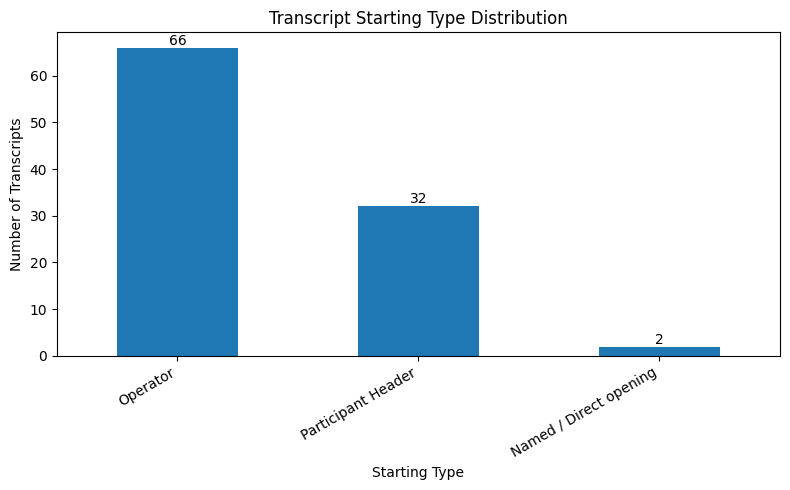

In [21]:
plot_transcript_start_types(earnings_df)

In [22]:
edgar_df

,filename,cik,year,section_1,section_1A,section_1B,section_2,section_3,section_4,section_5,...,section_8,section_9,section_9A,section_9B,section_10,section_11,section_12,section_13,section_14,section_15
0,103682_2020.htm,103682,2020,"Item 1. Business\nGENERAL\nDominion Energy, he...",Item 1A. Risk Factors\nThe Companies’ business...,Item 1B. Unresolved Staff Comments\nNone.\nIte...,"Item 2. Properties\nAs of December 31, 2020, D...","Item 3. Legal Proceedings\nFrom time to time, ...",Item 4. Mine Safety Disclosures\nNot applicabl...,"Item 5. Market for Registrant’s Common Equity,...",...,Item 8. Financial Statements and Supplementary...,Item 9. Changes in and Disagreements With Acco...,Item 9A. Controls and Procedures\nDominion Ene...,Item 9B. Other Information\nNone.\nPart III\nI...,"Item 10. Directors, Executive Officers and Cor...",Item 11. Executive Compensation\nDOMINION ENER...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14. Principal Accountant Fees and Service...,Item 15. Exhibits and Financial Statement Sche...
1,1688126_2020.htm,1688126,2020,Item 1. Business\nThe Crypto Company (the “Com...,Item 1A. Risk Factors\nNot Applicable\nItem 1B.,Item 1B. Unresolved Staff Comments\nNot applic...,Item 2. Properties\nDue to the onset of Covid-...,Item 3. Legal Proceedings\nSee discussion of l...,Item 4. Mine Safety Disclosures\nNot applicabl...,"Item 5. Market for Common Equity, Related Stoc...",...,Item 8. Financial Statements and Supplementary...,Item 9. Changes in and Disagreements with Acco...,Item 9A. Controls and Procedures\nInternal Con...,"Item 9B. Other Information\nOn March 24, 2021,...","Item 10. Directors, Executive Officers and Cor...",Item 11. Executive Compensation\nSummary Compe...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14. Principal Accounting Fees and Service...,"Item 15. Exhibits, Financial Statement Schedul..."
2,1784851_2020.htm,1784851,2020,Item 1. Business.\nWe are a Cayman Islands exe...,Item 1A. Risk Factors.\nYou should carefully c...,Item 1B. Unresolved Staff Comments.\nNot appli...,Item 2. Properties.\nWe do not own any real es...,Item 3. Legal Proceedings.\nTo the knowledge o...,Item 4. Mine Safety Disclosures.\nNot applicab...,"Item 5. Market for Registrant’s Common Equity,...",...,Item 8.Financial Statements and Supplementary ...,Item 9.Changes in and Disagreements with Accou...,Item 9A.Controls and Procedures.\nEvaluation o...,Item 9B. Other Information.\nNone.\nPART III\n...,"Item 10. Directors, Executive Officers and Cor...",Item 11. Executive Compensation.\nCompensation...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14.Principal Accountant Fees and Services...,"Item 15.Exhibits, Financial Statement Schedule..."
3,1685570_2020.htm,1685570,2020,ITEM 1. BUSINESS\nOVERVIEW\nWe were incorporat...,ITEM 1A. RISK FACTORS\nInvesting in our common...,ITEM 1B. UNRESOLVED STAFF COMMENTS\nNot Applic...,ITEM 2. PROPERTIES\nOur principal executive of...,"ITEM 3. LEGAL PROCEEDINGS\nFrom time to time, ...",ITEM 4. MINE SAFETY DISCLOSURES\nNot Applicabl...,"ITEM 5. MARKET FOR REGISTRANT’S COMMON EQUITY,...",...,ITEM 8. FINANCIAL STATEMENTS AND SUPPLEMENTARY...,ITEM 9. CHANGES IN AND DISAGREEMENTS WITH ACCO...,ITEM 9A. CONTROLS AND PROCEDURES\nManagement’s...,ITEM 9B. OTHER INFORMATION\nExcept as provided...,"ITEM 10. DIRECTORS, EXECUTIVE OFFICERS AND COR...",ITEM 11. EXECUTIVE COMPENSATION\nThe particula...,ITEM 12. SECURITY OWNERSHIP OF CERTAIN BENEFIC...,ITEM 13. CERTAIN RELATIONSHIPS AND RELATED TRA...,ITEM 14. PRINCIPAL ACCOUNTING FEES AND SERVICE...,"ITEM 15. EXHIBITS, FINANCIAL STATEMENT SCHEDUL..."
4,1635282_2020.htm,1635282,2020,Item 1. Business\nBusiness Combination\nRimini...,Item 1A - Risk Factors\nFactors that could cau...,Item 1B. Unresolved Staff Comments\nNone.\nIte...,Item 2. Properties\nOur principal executive

In [26]:
earnings_df.iloc[22]['transcript'][:310]

'\ufeff Operator : Good morning, ladies and gentlemen, and welcome to the MAA Third Quarter 2020 Earnings Conference Call. [Operator Instructions] As a reminder, this conference is being recorded today, October 29, 2020. I will now turn the conference over to Tim Argo, Senior Vice President, Finance for MAA. Tim Ar'

In [31]:
print(earnings_df.iloc[22]['transcript'][:400])

 Operator : Good morning, ladies and gentlemen, and welcome to the MAA Third Quarter 2020 Earnings Conference Call. [Operator Instructions] As a reminder, this conference is being recorded today, October 29, 2020. I will now turn the conference over to Tim Argo, Senior Vice President, Finance for MAA. Tim Argo : Thank you, Ashley, and good morning, everyone. This is Tim Argo, Senior Vice Presiden
